In [5]:
import cv2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import random
from glob import glob
import os
from tqdm.notebook import tqdm

import IPython.display as ipd

In [6]:
glob_path = [i for i in glob('Dataset\*\*\*.mp4')]
output_label = [i for i in glob('Dataset\*\*')]

glob_path,output_label

(['Dataset\\Adjectives\\1. loud\\MVI_5177.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5178.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5179.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5257.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5258.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5259.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5335.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5336.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_5337.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9289.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9290.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9291.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9368.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9369.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9370.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9448.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9449.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9450.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9534.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_9535.mp4',
  'Dataset\\Adjectives\\1. loud\\MVI_953

In [7]:
random_video = random.choice(glob_path)
print(random_video.split("\\")[-2:])

cap = cv2.VideoCapture(random_video)
print(f"Video Resolution: {cap.get(cv2.CAP_PROP_FRAME_WIDTH)} x {cap.get(cv2.CAP_PROP_FRAME_HEIGHT)}")
print(f"FPS: {cap.get(cv2.CAP_PROP_FPS)}")

ipd.Video(random_video,width=700)

['42. he', 'MVI_0007.mp4']
Video Resolution: 1920.0 x 1080.0
FPS: 25.0


In [8]:
cap = cv2.VideoCapture(random_video)
ret, img = cap.read()
print(f'Returned {ret} and img of shape {img.shape}')

Returned True and img of shape (1080, 1920, 3)


In [9]:
def display_cv2_img(img, figsize=(10, 10)):
    img_ = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img_)
    ax.axis("off")

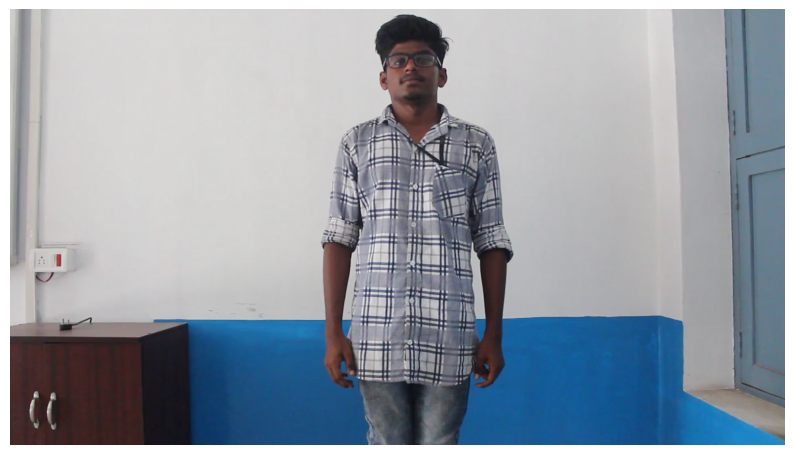

In [10]:
display_cv2_img(img)
cap.release()

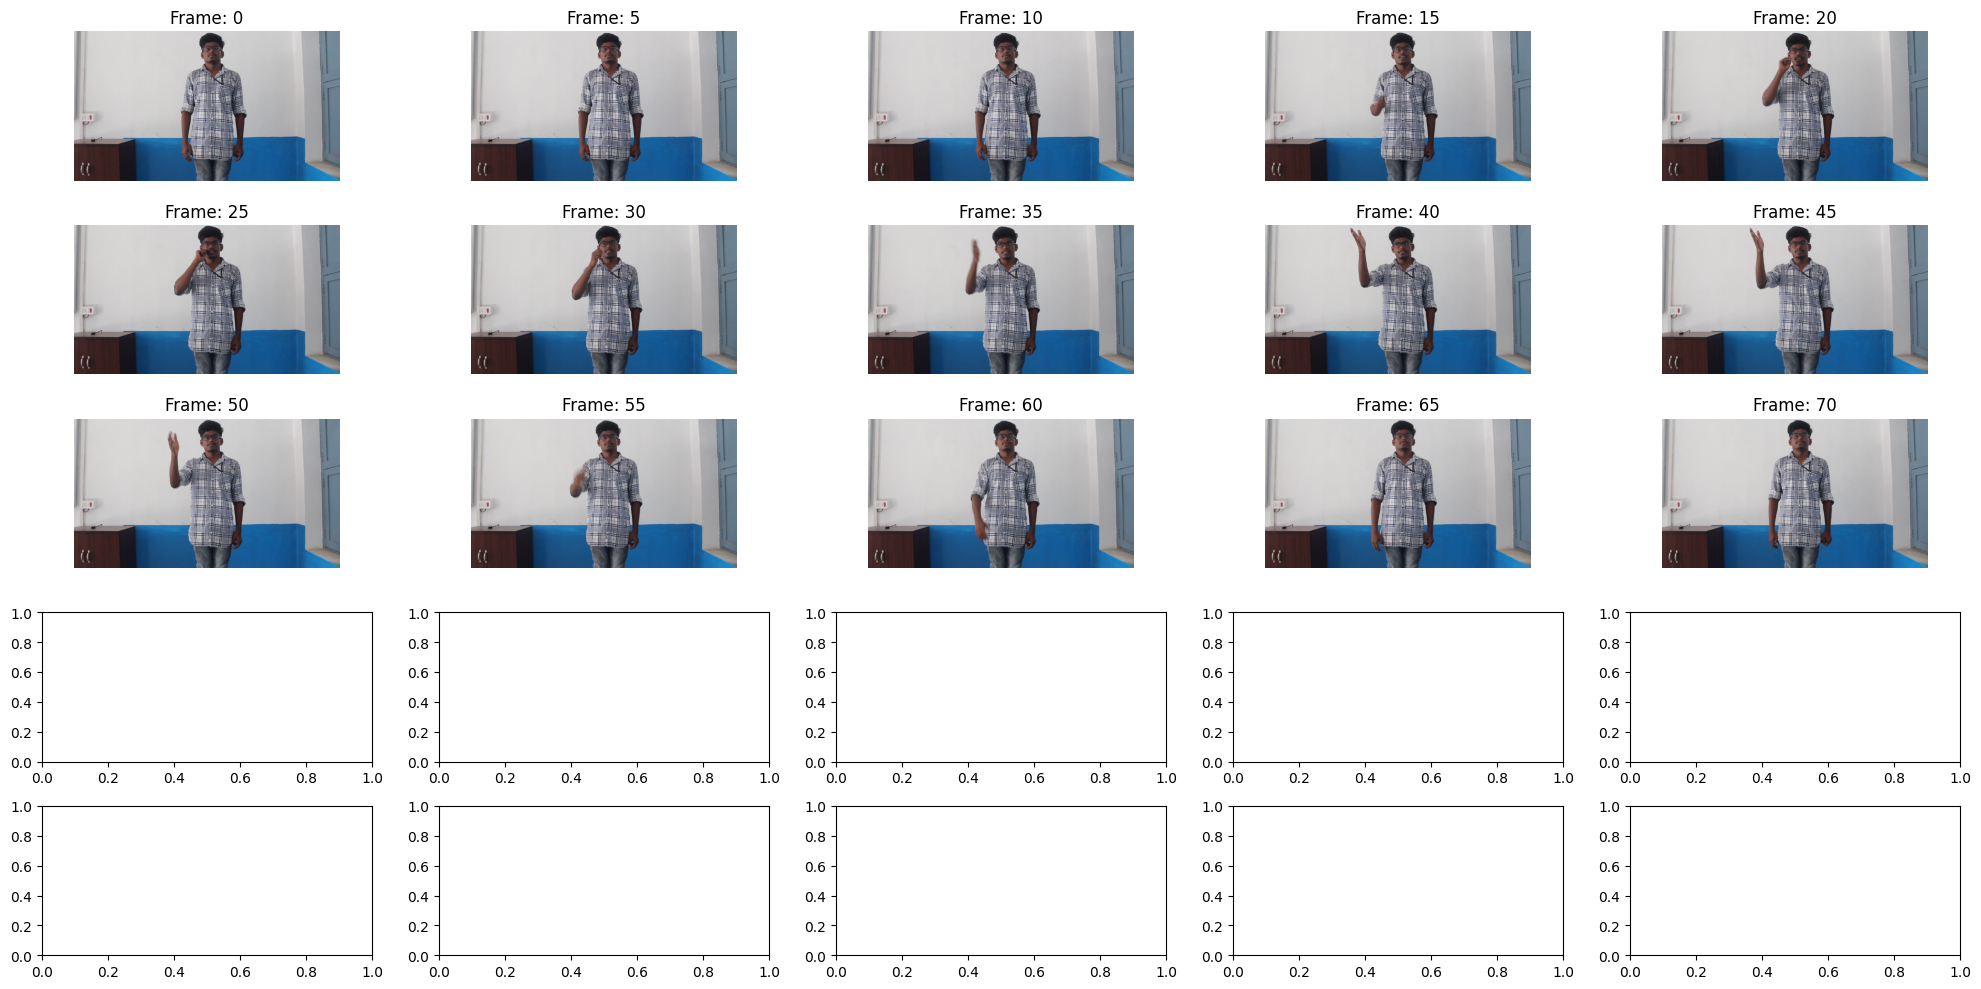

In [11]:
fig, axs = plt.subplots(5, 5, figsize=(20, 10))
axs = axs.flatten()

cap = cv2.VideoCapture(random_video)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))


img_idx = 0
for frame in range(n_frames):
    ret, img = cap.read()
    if ret == False:
        break
    if frame % 5 == 0:
        axs[img_idx].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axs[img_idx].set_title(f'Frame: {frame}')
        axs[img_idx].axis('off')
        img_idx += 1

plt.tight_layout()
plt.show()
cap.release()

## Vedio Augmentaion

1. Org  
2. Centre Crop
3. Flip
4. Upsample
5. Downsample

### Optional (Optional Experimentrs)
6. sharpen 
7. blurred
8. Frame Skipping

### Centre Crop

In [12]:
def centered_video(org_video, save_path, cap, n_frames):
    cap = cv2.VideoCapture(org_video)
    VIDEO_CODEC = "MP4V"
    fps = 25
    width = 600
    height = 1080
    out = cv2.VideoWriter(save_path,
                    cv2.VideoWriter_fourcc(*VIDEO_CODEC),
                    fps,
                    (width, height))


    for frame in range(n_frames):
        ret, img = cap.read()
        img = img[:,700:1300] # Cropping
        
        if ret == False:
            break
        out.write(img)

    out.release()
    cap.release()

### Flip


In [13]:
def flip_video(org_video, save_path, cap, n_frames):
    cap = cv2.VideoCapture(org_video)

    VIDEO_CODEC = "MP4V"
    fps = 25
    width = 1920
    height = 1080
    out = cv2.VideoWriter(save_path,
                    cv2.VideoWriter_fourcc(*VIDEO_CODEC),
                    fps,
                    (width, height))

    for frame in range(n_frames):
        ret, img = cap.read()
        img = img[:,::-1] # Flipping
        
        if ret == False:
            break
        
        out.write(img)

    out.release()
    cap.release()


### Downsampling

In [14]:
def downsample_video(org_video, save_path, cap, n_frames):
    cap = cv2.VideoCapture(org_video)

    
    VIDEO_CODEC = "MP4V"
    fps = 25
    width = 960
    height = 540
    out = cv2.VideoWriter(save_path,
                    cv2.VideoWriter_fourcc(*VIDEO_CODEC),
                    fps,
                    (width, height))


    for frame in range(n_frames):
        ret, img = cap.read()
        img = cv2.pyrDown(img) # Downsampling
        
        if ret == False:
            break
        
        out.write(img)

    out.release()
    cap.release()


### Upsampling


In [15]:
def upsample_video(org_video, save_path, cap, n_frames):
    cap = cv2.VideoCapture(org_video)

    VIDEO_CODEC = "MP4V"
    fps = 25
    width = 3840
    height = 2160
    out = cv2.VideoWriter(save_path,
                    cv2.VideoWriter_fourcc(*VIDEO_CODEC),
                    fps,
                    (width, height))



    for frame in range(n_frames):
        ret, img = cap.read()
        img = cv2.pyrUp(img) # Upsampling
        
        if ret == False:
            break
        
        out.write(img)

    out.release()
    cap.release()


## Genrating all the augmented content


In [31]:
for label in tqdm(glob('Dataset\*\*')): 
    label_name = " ".join(((label.split("\\")[-1]).split(" "))[1:]) # First seprated the label from dir then sep the label from its number and then join the label
    
    # Currently applying augmentation for include 50 dataset only
    if label_name in os.listdir("MP_data"):
        os.makedirs(os.path.join(label,"Augmentation"), exist_ok=True)
        videos = os.listdir(label)[1:]
        
        for video in tqdm(videos,desc=label.split("\\")[-1]):
            input_video = os.path.join(label, video)
            n_frames = int(cv2.VideoCapture(input_video).get(cv2.CAP_PROP_FRAME_COUNT))      

            save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_centered.mp4")
            centered_video(input_video, save_path, cap, n_frames)

            save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_flipped.mp4") 
            flip_video(input_video, save_path, cap, n_frames)

            save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_downsampled.mp4") 
            downsample_video(input_video, save_path, cap, n_frames)

            save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_upsampled.mp4") 
            upsample_video(input_video, save_path, cap, n_frames)
    
        

  0%|          | 0/262 [00:00<?, ?it/s]

1. loud:   0%|          | 0/21 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
for label in tqdm(glob('Dataset\*\*')): 
    os.makedirs(os.path.join(label,"Augmentation"), exist_ok=True)
    videos = os.listdir(label)[1:]
   
    
    for video in tqdm(videos,desc=label.split("\\")[-1]):
        input_video = os.path.join(label, video)
        n_frames = int(cv2.VideoCapture(input_video).get(cv2.CAP_PROP_FRAME_COUNT))      

        save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_centered.mp4")
        centered_video(input_video, save_path, cap, n_frames)

        save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_flipped.mp4") 
        flip_video(input_video, save_path, cap, n_frames)

        save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_downsampled.mp4") 
        downsample_video(input_video, save_path, cap, n_frames)

        save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_upsampled.mp4") 
        upsample_video(input_video, save_path, cap, n_frames)
    

  0%|          | 0/262 [00:00<?, ?it/s]

Dataset\Adjectives\1. loud
Dataset\Adjectives\2. quiet
Dataset\Adjectives\3. happy
Dataset\Animals\1. Dog
Dataset\Animals\4. Bird
Dataset\Animals\5. Cow
Dataset\Society\2. Death


## Extracting mediapipe points from augmented vedios

In [16]:
# Setting up for mediapipe extraction of augmented videos
import mediapipe as mp

mp_holistic = mp.solutions.holistic 
mp_drawing = mp.solutions.drawing_utils 

In [17]:
def mediapipe_detection(image, model) -> tuple:
    image_ = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) 
    image_.flags.writeable = False                  
    results = model.process(image_) 
    image_.flags.writeable = True                   
    image = cv2.cvtColor(image_, cv2.COLOR_RGB2BGR) 
    return image, results

In [18]:
def extract_keypoints(results) -> np.array:
    
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    
    return np.concatenate([pose, face, lh, rh])

In [23]:
# Cell for checking vedios that havent been extracted yet
DATA_PATH = glob("MP_data\*\*.npy")
video_path = glob("Dataset\*\*\*.mp4")

removed_path_npy = []
for i in DATA_PATH:
    if "_centered" not in i and "_flipped" not in i and "_downsampled" not in i and "_upsampled" not in i :
        removed_path_npy.append(i)

removed_path_mp4 = []
for i in glob("Dataset\*\*"):
    label = ((i.split("\\")[-1]).split(" ")[1:])[0]
    if label in [i.split("\\")[-1] for i in glob("MP_data\*")]:
        removed_path_mp4.append(i)


mp4_path = []
for i in removed_path_mp4:
    for j in glob(f"{i}\*.mp4"):
        mp4_path.append(j)


mp4 = [i.split("\\")[-1].removesuffix(".mp4") for i in mp4_path]
npy = [j.split("\\")[-1].removesuffix(".npy") for j in removed_path_npy]

extract = []
for i in range(len(mp4)):
    file = mp4[i].split("\\")[-1].removesuffix(".mp4")

    if file not in npy:
        extract.append(video_path[i])        
    
print(extract)

['Dataset\\Adjectives\\1. loud\\MVI_9289.mp4', 'Dataset\\Adjectives\\1. loud\\MVI_9369.mp4', 'Dataset\\Adjectives\\1. loud\\MVI_9534.mp4', 'Dataset\\Adjectives\\1. loud\\MVI_9536.mp4', 'Dataset\\Adjectives\\10. Mean\\MVI_9592.mp4', 'Dataset\\Adjectives\\11. rich\\MVI_9596.mp4', 'Dataset\\Adjectives\\11. rich\\MVI_9734.mp4', 'Dataset\\Adjectives\\12. poor\\MVI_9603.mp4', 'Dataset\\Adjectives\\12. poor\\MVI_9737.mp4', 'Dataset\\Adjectives\\12. poor\\MVI_9738.mp4', 'Dataset\\Adjectives\\13. thick\\MVI_9605.mp4', 'Dataset\\Adjectives\\14. thin\\MVI_9609.mp4', 'Dataset\\Adjectives\\14. thin\\MVI_9612.mp4', 'Dataset\\Adjectives\\15. expensive\\MVI_9615.mp4', 'Dataset\\Adjectives\\15. expensive\\MVI_9748.mp4', 'Dataset\\Adjectives\\16. cheap\\MVI_9751.mp4', 'Dataset\\Adjectives\\16. cheap\\MVI_9752.mp4', 'Dataset\\Adjectives\\17. flat\\MVI_9622.mp4', 'Dataset\\Adjectives\\17. flat\\MVI_9755.mp4', 'Dataset\\Adjectives\\17. flat\\MVI_9756.mp4', 'Dataset\\Adjectives\\17. flat\\MVI_9758.mp4', 'Da

In [25]:
DATA_PATH = "MP_data\\"
mp_holistic = mp.solutions.holistic
holistic = mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5)

# for label in tqdm(glob('Dataset\*\*')): 
#     vedios = os.listdir(os.path.join(label,"Augmentation"))
    
for video in tqdm(extract):             
    
    cap = cv2.VideoCapture(video)
    all_keypoints = []
    keypoints = np.array(None)
        
    while cap.isOpened():           
        # Read feed
        ret, frame = cap.read()
        if not ret:
            break
        
        # Make detections
        image, results = mediapipe_detection(frame, holistic)
            
        #Collecting 3D landmarks for a single frame
        keypoints = extract_keypoints(results)
        all_keypoints.append(keypoints)        
        
    all_keypoints = np.vstack(all_keypoints)
    
    # Saving Landmarks
    path = video.split("/")
    
    # Getting Current action of the video
    action = (video.split("\\")[-2]).split(" ")[-1]
    
    #Get the sequence number
    sequence = video.split("\\")[-1][:-4]
    
    npy_path = os.path.join(DATA_PATH, action, sequence)
    
    
    try:
        np.save(npy_path, all_keypoints)
    except:
        print(npy_path)

    cap.release()
    

  0%|          | 0/263 [00:00<?, ?it/s]

MP_data\Mean\MVI_9592
MP_data\rich\MVI_9596
MP_data\rich\MVI_9734
MP_data\poor\MVI_9603
MP_data\poor\MVI_9737
MP_data\poor\MVI_9738
MP_data\thick\MVI_9605
MP_data\thin\MVI_9609
MP_data\thin\MVI_9612
MP_data\expensive\MVI_9615
MP_data\expensive\MVI_9748
MP_data\cheap\MVI_9751
MP_data\cheap\MVI_9752
MP_data\flat\MVI_9622
MP_data\flat\MVI_9755
MP_data\flat\MVI_9756
MP_data\flat\MVI_9758
MP_data\curved\MVI_9762
MP_data\male\MVI_9637
MP_data\male\MVI_9640
MP_data\male\MVI_9763
MP_data\male\MVI_9765
MP_data\female\MVI_9642
MP_data\female\MVI_9644
MP_data\female\MVI_9767
MP_data\female\MVI_9768
MP_data\female\MVI_9770
MP_data\tight\MVI_9647
MP_data\tight\MVI_9771
MP_data\loose\MVI_9653
MP_data\high\MVI_9655
MP_data\high\MVI_9657
MP_data\high\MVI_9781
MP_data\high\MVI_9782
MP_data\low\MVI_9659
MP_data\soft\MVI_9664
MP_data\soft\MVI_9789
MP_data\hard\MVI_9794
MP_data\shallow\MVI_9674
MP_data\shallow\MVI_9804
MP_data\clean\MVI_9680
MP_data\clean\MVI_9808
MP_data\dirty\MVI_9812
MP_data\strong\MVI